In [1]:
%pip install tensorflow pyarrow 
%pip install pandas  
%pip install scikit-learn 
%pip install matplotlib 
%pip install requests


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np 
import pandas as pd 
import tensorflow as tf 
import requests
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout


Setup the Environment to generate synthetic stock price data

In [3]:
import numpy as np
import pandas as pd

# Create a synthetic stock price dataset
np.random.seed(42)
data_length = 2000  # Adjust data length as needed
trend = np.linspace(100, 200, data_length)
noise = np.random.normal(0, 2, data_length)
synthetic_data = trend + noise

# Create a DataFrame and save as 'stock_prices.csv'
data = pd.DataFrame(synthetic_data, columns=['Close'])
data.to_csv('stock_prices.csv', index=False)
print("Synthetic stock_prices.csv created and loaded.")

Synthetic stock_prices.csv created and loaded.


In [4]:
# Load the dataset 
data = pd.read_csv('stock_prices.csv') 
data = data[['Close']].values 

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data)

# Prepare the data for training
def create_dataset(data, time_step=1):
    X, Y = [], []

    for i in range(len(data)-time_step-1):
        a = data[i:(i+time_step), 0]
        X.append(a)
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 100
X, Y = create_dataset(data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

print("Shape of X:", X.shape) 
print("Shape of Y:", Y.shape) 

Shape of X: (1899, 100, 1)
Shape of Y: (1899,)


Implement Multi-Head Self-Attention

In [5]:
class MultiHeadSelfAttention(Layer): 

    def __init__(self, embed_dim, num_heads=8): 
        super(MultiHeadSelfAttention, self).__init__() 
        self.embed_dim = embed_dim 
        self.num_heads = num_heads 
        self.projection_dim = embed_dim // num_heads 
        self.query_dense = Dense(embed_dim) 
        self.key_dense = Dense(embed_dim) 
        self.value_dense = Dense(embed_dim) 
        self.combine_heads = Dense(embed_dim) 


    def attention(self, query, key, value): 
        score = tf.matmul(query, key, transpose_b=True) 
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32) 
        scaled_score = score / tf.math.sqrt(dim_key) 
        weights = tf.nn.softmax(scaled_score, axis=-1) 
        output = tf.matmul(weights, value) 
        return output, weights 

    def split_heads(self, x, batch_size): 
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim)) 
        return tf.transpose(x, perm=[0, 2, 1, 3]) 

    def call(self, inputs): 
        batch_size = tf.shape(inputs)[0] 
        query = self.query_dense(inputs) 
        key = self.key_dense(inputs) 
        value = self.value_dense(inputs) 
        query = self.split_heads(query, batch_size) 
        key = self.split_heads(key, batch_size) 
        value = self.split_heads(value, batch_size) 
        attention, _ = self.attention(query, key, value) 
        attention = tf.transpose(attention, perm=[0, 2, 1, 3]) 
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim)) 
        output = self.combine_heads(concat_attention) 
        return output 

 

In the above code:

The MultiHeadSelfAttention layer implements the multi-head self-attention mechanism, which allows the model to focus on different parts of the input sequence simultaneously.

The attention parameter computes the attention scores and weighted sum of the values.

The split_heads parameter splits the input into multiple heads for parallel attention computation.

The call method applies the self-attention mechanism and combines the heads.

Implement Transformer block

In [6]:
class TransformerBlock(Layer): 

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerBlock, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 


    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 


In the above code:

The TransformerBlock layer combines multi-head self-attention with a feed-forward neural network and normalization layers.

Dropout is used to prevent overfitting.

The call method applies the self-attention, followed by the feedforward network with residual connections and layer normalization.

Implement Encoder Layer


In [7]:
class EncoderLayer(Layer): 

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(EncoderLayer, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 

 

    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 




In the above code:

The EncoderLayer is similar to the TransformerBlock but is a reusable layer in the Transformer architecture.

It consists of a MultiHeadSelfAttention mechanism followed by a feedforward neural network.

Both sub-layers have residual connections around them, and layer normalization is applied to the output of each sub-layer.

The call method applies the self-attention, followed by the feedforward network, with residual connections and layer normalization.

Implement Transformer encoder

In [8]:
import tensorflow as tf 
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout 

class MultiHeadSelfAttention(Layer): 
    def __init__(self, embed_dim, num_heads=8): 
        super(MultiHeadSelfAttention, self).__init__() 
        self.embed_dim = embed_dim 
        self.num_heads = num_heads 
        self.projection_dim = embed_dim // num_heads 
        self.query_dense = Dense(embed_dim) 
        self.key_dense = Dense(embed_dim) 
        self.value_dense = Dense(embed_dim) 
        self.combine_heads = Dense(embed_dim) 
 

    def attention(self, query, key, value): 
        score = tf.matmul(query, key, transpose_b=True) 
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32) 
        scaled_score = score / tf.math.sqrt(dim_key) 
        weights = tf.nn.softmax(scaled_score, axis=-1) 
        output = tf.matmul(weights, value) 
        return output, weights 


    def split_heads(self, x, batch_size): 
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim)) 
        return tf.transpose(x, perm=[0, 2, 1, 3]) 


    def call(self, inputs): 
        batch_size = tf.shape(inputs)[0] 
        query = self.query_dense(inputs) 
        key = self.key_dense(inputs) 
        value = self.value_dense(inputs) 
        query = self.split_heads(query, batch_size) 
        key = self.split_heads(key, batch_size) 
        value = self.split_heads(value, batch_size) 
        attention, _ = self.attention(query, key, value) 
        attention = tf.transpose(attention, perm=[0, 2, 1, 3]) 
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim)) 
        output = self.combine_heads(concat_attention) 
        return output 

class TransformerBlock(Layer): 
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerBlock, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 
 

    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 

class TransformerEncoder(Layer): 
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerEncoder, self).__init__() 
        self.num_layers = num_layers 
        self.embed_dim = embed_dim 
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate) for _ in range(num_layers)] 
        self.dropout = Dropout(rate) 

    def call(self, inputs, training=False): 
        x = inputs 
        for i in range(self.num_layers): 
            x = self.enc_layers[i](x, training=training) 
        return x 

# Example usage 
embed_dim = 128 
num_heads = 8 
ff_dim = 512 
num_layers = 4 

transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim) 
inputs = tf.random.uniform((1, 100, embed_dim)) 
outputs = transformer_encoder(inputs, training=False)  # Use keyword argument for 'training' 
print(outputs.shape)  # Should print (1, 100, 128) 

(1, 100, 128)


Build and Compile the Transformer model

In [9]:
# Define the necessary parameters 

embed_dim = 128 
num_heads = 8 
ff_dim = 512 
num_layers = 4 

# Define the Transformer Encoder 
transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim) 

# Build the model 
input_shape = (X.shape[1], X.shape[2]) 
inputs = tf.keras.Input(shape=input_shape) 

# Project the inputs to the embed_dim 
x = tf.keras.layers.Dense(embed_dim)(inputs) 
encoder_outputs = transformer_encoder(x) 
flatten = tf.keras.layers.Flatten()(encoder_outputs) 
outputs = tf.keras.layers.Dense(1)(flatten) 
model = tf.keras.Model(inputs, outputs) 

# Compile the model 
model.compile(optimizer='adam', loss='mse') 

# Summary of the model 
model.summary() 


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100, 128)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 100, 128)       │       793,088 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,145 (3.08 MB)

 Trainable params: 806,145 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

Train the Transformer model

In [10]:
# Train the model
model.fit(X, Y, epochs=20, batch_size=32)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 226ms/step - loss: 4.2781
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - loss: 0.2535
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - loss: 0.1374
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - loss: 0.1356
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 239ms/step - loss: 0.1413
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - loss: 0.1118
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - loss: 0.1189
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - loss: 0.1405
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - loss: 0.1002
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step - loss: 0.0923
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - loss: 0.0938
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step - loss: 0.0891
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - loss: 0.1249
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - loss: 0.0687
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 

Evaluate and Make Predictions

60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step


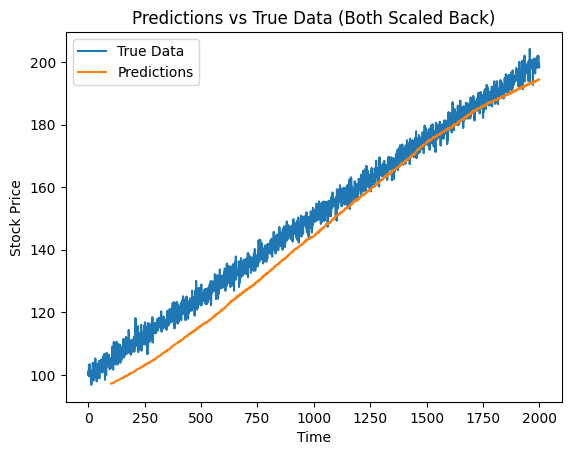

In [11]:
# Make predictions 
predictions = model.predict(X) 
predictions = scaler.inverse_transform(predictions) 

# Prepare true values for comparison
true_values = scaler.inverse_transform(data.reshape(-1, 1))

# Plot the predictions vs true values
import matplotlib.pyplot as plt 

plt.plot(true_values, label='True Data') 
plt.plot(np.arange(time_step, time_step + len(predictions)), predictions, label='Predictions') 
plt.xlabel('Time') 
plt.ylabel('Stock Price') 
plt.legend() 
plt.title('Predictions vs True Data (Both Scaled Back)')
plt.show() 


In [13]:
# Make predictions 
predictions = model.predict(X) 
predictions = scaler.inverse_transform(predictions) 

# Prepare true values
true_values = scaler.inverse_transform(data.reshape(-1, 1))

# CORREÇÃO AQUI
true = true_values[time_step:time_step + len(predictions)]

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(true, predictions)
mse = mean_squared_error(true, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(true, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step
MAE: 5.597648673151986
MSE: 42.8307055796763
RMSE: 6.544517215171513
R²: 0.9434506788568333


erra ~6 unidades
explica 94% dos dados


Exercise 1: Add dropout to the Transformer model

Objective: Understand how to add dropout layers to the Transformer model to prevent overfitting.

Instructions:

Add a dropout layer after the Flatten layer in the model.

Set the dropout rate to 0.5

In [14]:
from tensorflow.keras.layers import Dropout 

# Add a dropout layer after the Flatten layer 

flatten = tf.keras.layers.Flatten()(encoder_outputs) 

dropout = Dropout(0.5)(flatten) 

outputs = tf.keras.layers.Dense(1)(dropout) 

# Build the model 

model = tf.keras.Model(inputs, outputs) 

# Compile the model 

model.compile(optimizer='adam', loss='mse') 

# Train the model 

model.fit(X, Y, epochs=20, batch_size=32) 

# Evaluate the model 

loss = model.evaluate(X, Y) 

print(f'Test loss: {loss}') 

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - loss: 2.7267
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - loss: 0.9249
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - loss: 0.3204
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - loss: 0.1233
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - loss: 0.0763
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 222ms/step - loss: 0.0582
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 222ms/step - loss: 0.0526
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - loss: 0.0429
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - loss: 0.0377
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - loss: 0.0383
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - loss: 0.0344
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - loss: 0.0273
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - loss: 0.0237
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - loss: 0.0191
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 

Exercise 2: Experiment with different batch sizes

Objective: Observe the impact of different batch sizes on model performance.

Instructions:

Train the model with a batch size of 16.

Train the model with a batch size of 64.

Compare the training time and performance.

In [16]:
# Train the model with batch size 16
model.fit(X, Y, epochs=20, batch_size=16)

# Evaluate the model
loss = model.evaluate(X, Y)
print(f'Test loss with batch size 16: {loss}')

# Train the model with batch size 64
model.fit(X, Y, epochs=20, batch_size=64)

# Evaluate the model
loss = model.evaluate(X, Y)
print(f'Test loss with batch size 64: {loss}')

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0266
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0285
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0266
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0222
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - loss: 0.0296
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0206
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0178
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - loss: 0.0251
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - loss: 0.0281
Epoch 10/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0190
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - loss: 0.0158
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0193
Epoch 13/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0180
Epoch 14/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0159
Epoch 15/20
119

Exercise 3: Use a different activation function

Objective: Understand how different activation functions impact the model performance.

Instructions:

Change the activation function of the Dense layer to tanh.

Train and evaluate the model.

In [17]:
# Change the activation function of the Dense layer to tanh
outputs = tf.keras.layers.Dense(1, activation='tanh')(flatten)

# Build the model
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X, Y, epochs=20, batch_size=32)

# Evaluate the model
loss = model.evaluate(X, Y)
print(f'Test loss with tanh activation: {loss}')

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 212ms/step - loss: 0.3186
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - loss: 0.2967
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - loss: 0.2967
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - loss: 0.2967
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step - loss: 0.2967
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - loss: 0.2967
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - loss: 0.2965
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - loss: 0.3242
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - loss: 0.2967
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - loss: 0.2967
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 220ms/step - loss: 0.2967
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - loss: 0.2967
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - loss: 0.3832
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - loss: 0.2967
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 